In [1]:
# installing required libraries
!pip install pennylane kagglehub torch torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 44.1 MB/s eta 0:00:00


In [2]:
# importing required libraries
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import pennylane as qml
import kagglehub

In [3]:
# device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
# downloading the dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
dataset_path = path + "/chest_xray"
print(dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia/chest_xray


In [5]:
# image preprocessing
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [6]:
# Loading dataset
train_dataset = torchvision.datasets.ImageFolder(
    dataset_path + "/train",
    transform=transform
)
test_dataset = torchvision.datasets.ImageFolder(
    dataset_path + "/test",
    transform=transform
)
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

test_loader = DataLoader(test_dataset,batch_size=32)

In [7]:
# handling class imbalance
class_counts = [1341, 3875]
weights = torch.tensor([
    1/class_counts[0],
    1/class_counts[1]
], dtype=torch.float32)
weights = weights.to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

In [8]:
# Pretrained CNN Feature Extractor
resnet = models.resnet18(pretrained=True)
for param in resnet.parameters():
    param.requires_grad = False
resnet.fc = nn.Linear(resnet.fc.in_features,4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


In [9]:
# Quantum circuit
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [10]:
# Quantum Layer
weight_shapes = {"weights": (2, n_qubits)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

In [11]:
# Hybrid Quantum Model
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = resnet
        self.quantum = qlayer
        self.fc = nn.Linear(4,2)
    def forward(self,x):
        x = self.cnn(x)
        x = self.quantum(x)
        x = self.fc(x)
        return x

In [12]:
# Initializing Model
model = HybridModel()
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [13]:
# training the model
epochs = 8
for epoch in range(epochs):
    total_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss)

# saving the model
torch.save(model.state_dict(), "model.pth")
print("Model saved successfully!")

Epoch: 1 Loss: 85.5839416384697
Epoch: 2 Loss: 61.378234684467316
Epoch: 3 Loss: 49.459651574492455
Epoch: 4 Loss: 42.563830718398094
Epoch: 5 Loss: 38.405614629387856
Epoch: 6 Loss: 35.28881314396858
Epoch: 7 Loss: 33.305042289197445
Epoch: 8 Loss: 29.317803226411343
Model saved successfully!


In [16]:
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix

classes = ["Normal", "Pneumonia"]

correct = 0
total = 0
printed = False

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # Converting logits to probabilities
        probs = F.softmax(outputs, dim=1)

        # Printing probabilities for first sample only
        if not printed:
            for i, prob in enumerate(probs[0]):
                print(f"{classes[i]} Probability: {prob.item()*100:.2f}%")

            confidence, pred_sample = torch.max(probs, 1)

            print("\nFinal Prediction:", classes[pred_sample[0].item()])
            print("Confidence: {:.2f}%".format(confidence[0].item()*100))

            printed = True

        # Predictions for accuracy + metrics
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Store for report
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Final accuracy
accuracy = 100 * correct / total
print("\nQuantum Hybrid Accuracy: {:.2f}%".format(accuracy))

Normal Probability: 84.37%
Pneumonia Probability: 15.63%

Final Prediction: Normal
Confidence: 84.37%

Quantum Hybrid Accuracy: 82.05%



Confusion Matrix:
 [[132 102]
 [ 10 380]]


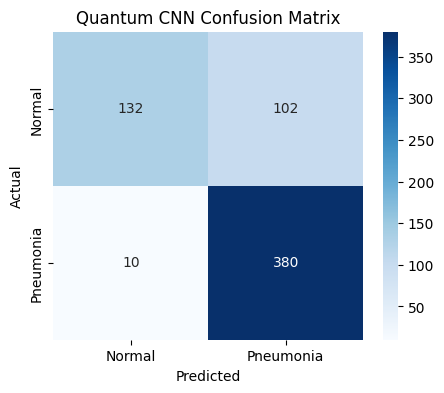


Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.56      0.70       234
   Pneumonia       0.79      0.97      0.87       390

    accuracy                           0.82       624
   macro avg       0.86      0.77      0.79       624
weighted avg       0.84      0.82      0.81       624



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix:\n", cm)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Pneumonia"],
            yticklabels=["Normal","Pneumonia"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Quantum CNN Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Normal", "Pneumonia"]))